# FoodWise Reads: Improved Food Book Recommender
Ironhack project covering web scraping, APIs, EDA, TF-IDF, SVD, K-Means, PCA, SQL and Streamlit.

In [1]:
import json, joblib, sqlite3
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import sparse
from src.collect_data import collect_all
from src.train_model import train
from src.database import build_database, example_queries
from src.recommender import recommend_books

## 1. Data collection
The collection script combines 500 scraped cookbook records with 700 balanced food-domain API records. After title-author deduplication, the catalogue contains 1,196 unique books and exceeds the 1,050-book submission target. Run this cell only when a fresh collection is needed.

In [2]:
# collection_summary = collect_all('data')
# collection_summary

## 2. Cleaning and initial exploration

In [3]:
books = pd.read_csv('data/books_combined.csv')
print('Shape:', books.shape)
display(books.head())
display(books.isna().mean().sort_values(ascending=False).to_frame('missing_share'))
display(books.groupby('source').size().to_frame('books'))

Shape: (1196, 13)


,title,authors,average_rating,rating_count,first_publish_year,edition_count,subjects,languages,cover_url,book_url,source,source_topic,source_rank
0,The Joy of Cooking,Irma S. Rombauer,4.12,203319.0,NaN,NaN,general cooking | cookbooks | cooking | food a...,eng,https://i.gr-assets.com/images/S/compressed.ph...,https://www.goodreads.com/book/show/327847.The...,Goodreads web scraping,general cooking,1.0
1,Mastering the Art of French Cooking,Julia Child,4.25,80003.0,NaN,NaN,world cuisines | cookbooks | cooking | food an...,eng,https://i.gr-assets.com/images/S/compressed.ph...,https://www.goodreads.com/book/show/129650.Mas...,Goodreads web scraping,world cuisines,2.0
2,Better Homes and Gardens New Cook Book,Better Homes and Gardens,4.15,141576.0,NaN,NaN,general cooking | cookbooks | cooking | food a...,eng,https://i.gr-assets.com/images/S/compressed.ph...,https://www.goodreads.com/book/show/411053.Bet...,Goodreads web scraping,general cooking,3.0
3,How to Cook Everything: Simple Recipes for Gre...,Mark Bittman,4.00,103530.0,NaN,NaN,quick and practical cooking | cookbooks | cook...,eng,https://i.gr-assets.com/images/S/compressed.ph...,https://www.goodreads.com/book/show/603204.How...,Goodreads web scraping,quick and practical cooking,4.0
4,The New Best Recipe,Cook's Illustrated,4.18,24624.0,NaN,NaN,general cooking | cookbooks | cooking | food a...,eng,https://i.gr-assets.com/images/S/compressed.ph...,https://www.goodreads.com/book/show/24019.The_...,Goodreads web scraping,general cooking,5.0


,missing_share
source_rank,0.581940
rating_count,0.418896
first_publish_year,0.418060
edition_count,0.418060
average_rating,0.418060
cover_url,0.098662
languages,0.015886
authors,0.000000
title,0.000000
subjects,0.000000


,books
source,
Goodreads web scraping,500
Open Library API,696


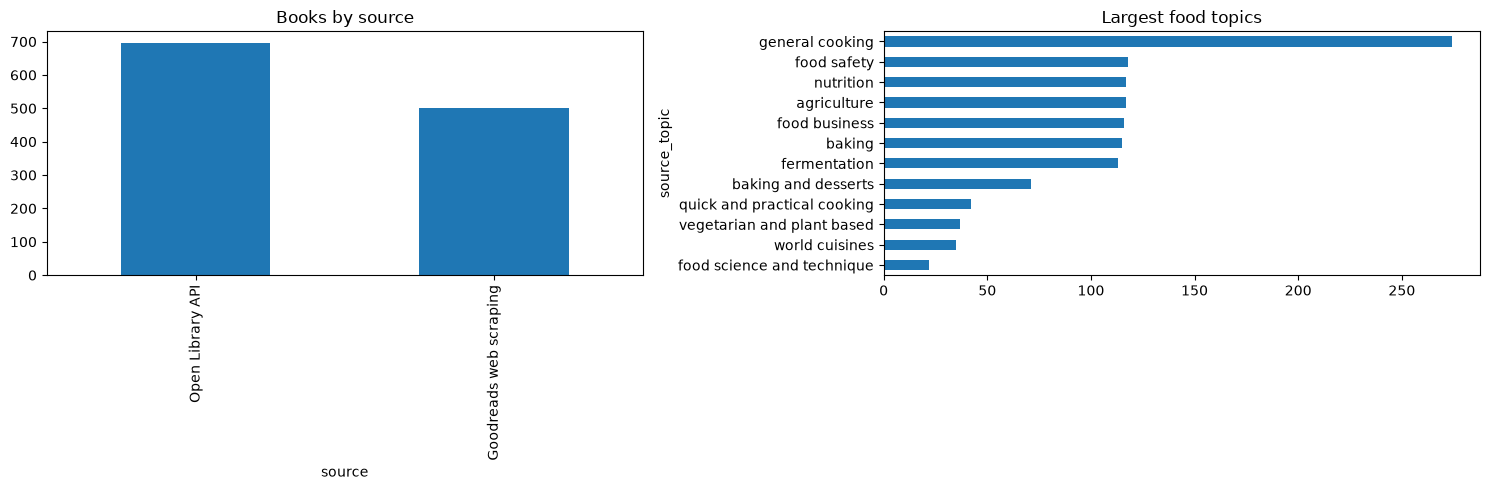

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
books['source'].value_counts().plot(kind='bar', ax=axes[0], title='Books by source')
books['source_topic'].value_counts().head(12).sort_values().plot(kind='barh', ax=axes[1], title='Largest food topics')
plt.tight_layout(); plt.show()

## 3. Leakage-controlled NLP and clustering
The modelling catalogue balances six food domains at 100 books each, producing 600 recommendation candidates. TF-IDF uses titles and cleaned subject metadata. Known domain and source-topic labels are held out. Candidate SVD dimensions are compared at k=6, followed by five-seed stability testing.

books_collected                                                           1196
books_modelled                                                             600
books_in_app                                                              1196
recommendation_features                                                   2313
domains                                                                      6
selected_k                                                                   6
selected_svd_components                                                      6
silhouette                                                              0.6093
ari_vs_heldout_domain                                                   0.6665
nmi_vs_heldout_domain                                                   0.6667
stability_silhouette_min                                                0.6093
stability_silhouette_mean                                               0.6093
cluster_sizes                {'0': 81, '1': 125, '2'

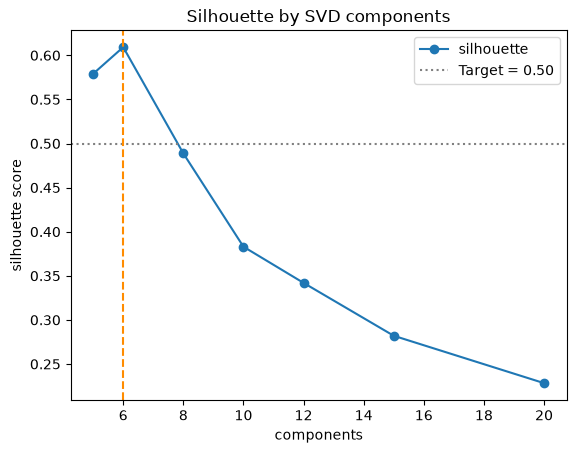

,seed,silhouette,ari,nmi
0,11,0.609256,0.666501,0.666743
1,22,0.609256,0.666501,0.666743
2,33,0.609256,0.666501,0.666743
3,42,0.609256,0.666501,0.666743
4,55,0.609256,0.666501,0.666743


In [5]:
# Re-run only when the catalogue or modelling choices change:
# metrics = train('data/books_combined.csv')
metrics = json.loads(Path('models/metrics.json').read_text())
display(pd.Series(metrics, name='result'))
selection = pd.read_csv('outputs/model_selection.csv')
selection.plot(x='components', y='silhouette', marker='o', title='Silhouette by SVD components')
plt.axhline(0.50, color='grey', linestyle=':', label='Target = 0.50')
plt.axvline(metrics['selected_svd_components'], color='darkorange', linestyle='--')
plt.ylabel('silhouette score'); plt.legend(); plt.show()
display(pd.read_csv('outputs/stability_scores.csv'))

## 4. PCA visualization
PCA reduces the selected six-dimensional representation to two dimensions for visualization only. K-Means uses the complete selected representation.

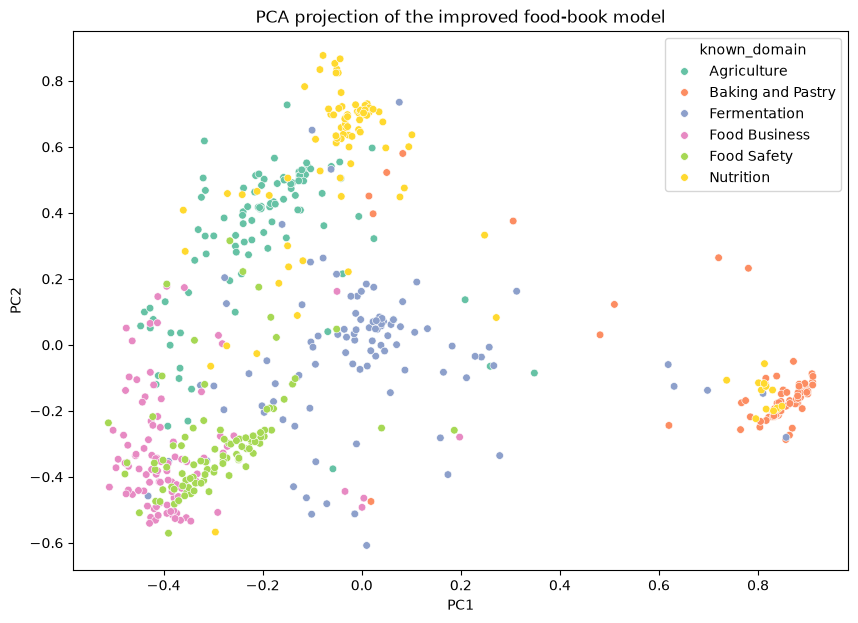

In [6]:
pca = pd.read_csv('outputs/pca_coordinates.csv')
plt.figure(figsize=(10, 7))
sns.scatterplot(data=pca, x='PC1', y='PC2', hue='known_domain', palette='Set2', s=30)
plt.title('PCA projection of the improved food-book model'); plt.show()

## 5. SQL storage and queries

In [7]:
build_database()
queries = example_queries()
display(queries['cluster_sizes'])
display(queries['top_rated'])
display(queries['sources'])

,cluster,books
0,3,602
1,1,149
2,5,126
3,4,119
4,2,108
5,0,92


,title,authors,average_rating,rating_count
0,The Encyclopedia of Cajun & Creole Cuisine,John D. Folse,4.71,238.0
1,A Treasury of Great Recipes,Mary Price,4.62,259.0
2,The Complete book of baking / Pillsbury,Editor,4.61,101.0
3,The Big Fat Duck Cookbook [Import Edition],Heston Blumenthal,4.56,136.0
4,"Supernatural: The Official Cookbook: Burgers, ...",Julie Tremaine,4.55,521.0
5,The Complete America's Test Kitchen TV Show Co...,America's Test Kitchen,4.54,4744.0
6,With a Measure of Grace: The Story and Recipes...,Blake Spalding,4.53,114.0
7,"Cook's Illustrated Cookbook: 2,000 Recipes fro...",Cook's Illustrated,4.51,2445.0
8,Essential Pépin: More Than 700 All-Time Favori...,Jacques Pépin,4.48,1037.0
9,"Culinaria Russia. Russland, Ukraine, Georgien,...",Na,4.48,111.0


,source,books
0,Goodreads web scraping,500
1,Open Library API,696


## 6. Recommendation demonstration
The function first restricts candidates to the selected book's cluster, then ranks them with cosine similarity.

In [8]:
clustered = pd.read_csv('data/clustered_books.csv')
matrix = sparse.load_npz('models/book_matrix.npz')
example_title = clustered.iloc[0]['title']
example_author = clustered.iloc[0]['authors']
result = recommend_books(example_title, clustered, matrix, example_author, number=5)
print('Selected:', result['selected'])
display(pd.DataFrame(result['recommendations']))

Selected: {'title': 'The Joy of Cooking', 'authors': 'Irma S. Rombauer'}


,title,authors,subjects,known_domain,source_topic,average_rating,year,similarity,cover_url,book_url
0,More Classic Italian Cooking,Marcella Hazan,world cuisines | cookbooks | cooking | food an...,General Cooking & Food,world cuisines,4.51,None,1.0,https://i.gr-assets.com/images/S/compressed.ph...,https://www.goodreads.com/book/show/21200.More...
1,Ratio: The Simple Codes Behind the Craft of Ev...,Michael Ruhlman,quick and practical cooking | cookbooks | cook...,General Cooking & Food,quick and practical cooking,4.09,None,1.0,https://i.gr-assets.com/images/S/compressed.ph...,https://www.goodreads.com/book/show/3931154-ratio
2,The Taste of Country Cooking,Edna Lewis,general cooking | cookbooks | cooking | food a...,General Cooking & Food,general cooking,4.44,None,1.0,https://i.gr-assets.com/images/S/compressed.ph...,https://www.goodreads.com/book/show/346029.The...
3,"Quiches, Kugels, and Couscous: My Search for J...",Joan Nathan,general cooking | cookbooks | cooking | food a...,General Cooking & Food,general cooking,4.09,None,1.0,https://i.gr-assets.com/images/S/compressed.ph...,https://www.goodreads.com/book/show/8140106-qu...
4,Italian Immigrant Cooking (Immigrant Cookbook ...,Elodia Rigante,world cuisines | cookbooks | cooking | food an...,General Cooking & Food,world cuisines,4.63,None,1.0,https://i.gr-assets.com/images/S/compressed.ph...,https://www.goodreads.com/book/show/1670915.It...


In [9]:
import subprocess
import sys
from pathlib import Path
from IPython.display import display, HTML

project_folder = Path(
    r"C:\Users\LENOVO\ironhack\Week_10\FoodWise_Reads_Improved"
)

if not (project_folder / "app.py").exists():
    raise FileNotFoundError("app.py was not found in the project folder.")

# Start Streamlit only if this notebook has not already started it.
if "streamlit_process" not in globals() or streamlit_process.poll() is not None:
    streamlit_process = subprocess.Popen(
        [
            sys.executable, "-m", "streamlit", "run", "app.py",
            "--server.port", "8501"
        ],
        cwd=str(project_folder)
    )

display(HTML(
    '<a href="http://localhost:8501" target="_blank">'
    'Click here to open FoodWise Reads</a>'
))

## 7. Conclusion
The expanded model achieved a silhouette score of 0.6093, ARI of 0.6665 and NMI of 0.6667 across 600 modelled books. The same silhouette was reproduced across five random seeds. The project therefore exceeds both the 1,050-book data target and the 0.50 clustering target.